In [ ]:
from galactoPINNs.data import generate_static_data
import galax.potential as gp

# A known, realistic Milky Way potential (disk + bulge + halo components).
# This is our STAND-IN for reality: we'll sample it to make training data.

# true_potential = gp.MilkyWayPotential()
# raw_datadict = generate_static_data(
#     galax_potential=true_potential,
#     n_samples_train=256,
#     n_samples_test=4096,
#     r_max_train=10,
#     r_max_test=150,
# )
raw_datadict = generate_static_data(
    galax_potential=true_potential,
    n_samples_train=2048,
    n_samples_test=4096,
    r_max_train=100,
    r_max_test=150,
)

In [125]:
# x (positions), a (accelerations), u (potential), 
# r (radius), for both a train and a val set.
#
# units: positions in kpc, acc in kpc/Myr^2, potential in kpc^2/Myr^2
print(raw_datadict.keys())

dict_keys(['x_train', 'a_train', 'u_train', 'r_train', 'x_val', 'a_val', 'u_val', 'r_val'])


In [126]:
for k, v in raw_datadict.items():
    print(f"{k:9s} shape={tuple(v.shape)} dtype={v.dtype}")

print("\nfirst training point:")
print(" position x=",raw_datadict["x_train"][0])
print(" acceleration a=",raw_datadict["a_train"][0])
print(" potential u=",raw_datadict["u_train"][0])
print(" radius r=",raw_datadict["r_train"][0])

x_train   shape=(2048, 3) dtype=float32
a_train   shape=(2048, 3) dtype=float32
u_train   shape=(2048,) dtype=float32
r_train   shape=(2048,) dtype=float32
x_val     shape=(4096, 3) dtype=float32
a_val     shape=(4096, 3) dtype=float32
u_val     shape=(4096,) dtype=float32
r_val     shape=(4096,) dtype=float32

first training point:
 position x= [ 6.640017    7.437017   -0.06593227]
 acceleration a= [-0.00362429 -0.00405931  0.00021779]
 potential u= -0.15223268
 radius r= 9.970125


In [127]:
import numpy as np
print("Calculating the radius by taking norm of position r =",np.sqrt(np.sum(raw_datadict["x_train"][0]**2)))

Calculating the radius by taking norm of position r = 9.970125


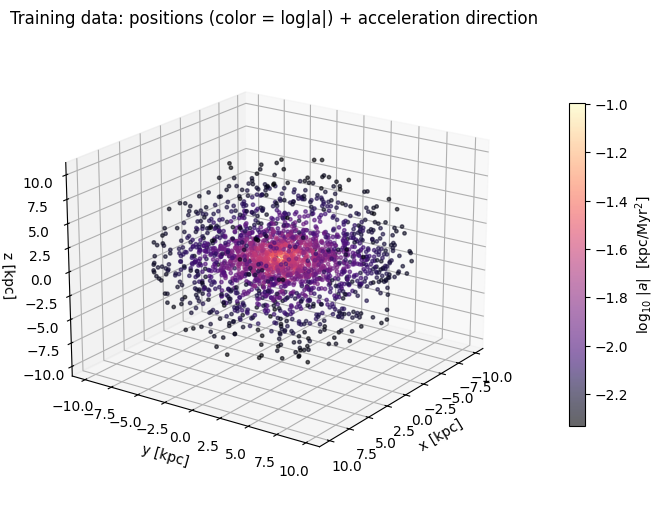

In [128]:
import numpy as np
import matplotlib.pyplot as plt

x = np.asarray(raw_datadict["x_train"])
a = np.asarray(raw_datadict["a_train"])
amag = np.linalg.norm(a, axis=1)          # acceleration magnitude, |a|
logamag = np.log10(amag)

# subsample the arrows so the plot isn't a hairball
rng = np.random.default_rng(0)
sub = rng.choice(len(x), size=1, replace=False)

fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(projection="3d")

# POINTS: position, colored by acceleration magnitude (log scale)
p = ax.scatter(x[:, 0], x[:, 1], x[:, 2], c=logamag, cmap="magma", s=6, alpha=0.6)

# ARROWS: direction only (unit length), just a subsample
ax.quiver(x[sub, 0], x[sub, 1], x[sub, 2],
          a[sub, 0], a[sub, 1], a[sub, 2],
          length=1, normalize=True, color="0.25", linewidth=0.6)

ax.set_xlabel("x [kpc]"); ax.set_ylabel("y [kpc]"); ax.set_zlabel("z [kpc]")
ax.set_title("Training data: positions (color = log|a|) + acceleration direction")
ax.view_init(elev=20, azim=35)            # pick a viewing angle
fig.colorbar(p, ax=ax, shrink=0.6, pad=0.1, label=r"$\log_{10}\,|a|$  [kpc/Myr$^2$]")
plt.show()


points in |z| < 8.0 kpc: 2002 of 2048


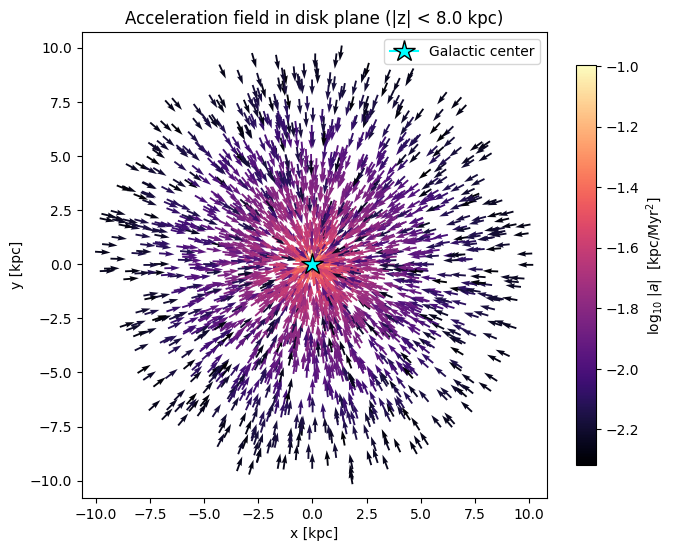

In [129]:
import numpy as np
import matplotlib.pyplot as plt

x = np.asarray(raw_datadict["x_train"])
a = np.asarray(raw_datadict["a_train"])
amag = np.linalg.norm(a, axis=1)

# take a thin slab near the disk plane (z ≈ 0) — a real slice, not a squashed projection
z_cut = 8.0                          # kpc
slab = np.abs(x[:, 2]) < z_cut
xs, as_, amags = x[slab], a[slab], amag[slab]
print(f"points in |z| < {z_cut} kpc: {slab.sum()} of {len(x)}")

# normalize the in-plane arrows to unit length (direction only); color carries magnitude
axy = as_[:, :2]
axy_unit = axy / np.linalg.norm(axy, axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(7.5, 6.5))
q = ax.quiver(xs[:, 0], xs[:, 1], axy_unit[:, 0], axy_unit[:, 1],
              np.log10(amags), cmap="magma",
              angles="xy", scale=30, width=0.004, pivot="mid")
ax.plot(0, 0, marker="*", ms=16, color="cyan", mec="k", label="Galactic center")
ax.set_aspect("equal")
ax.set_xlabel("x [kpc]"); ax.set_ylabel("y [kpc]")
ax.set_title(f"Acceleration field in disk plane (|z| < {z_cut} kpc)")
ax.legend(loc="upper right")
fig.colorbar(q, ax=ax, shrink=0.8, label=r"$\log_{10}\,|a|$  [kpc/Myr$^2$]")
plt.show()


In [130]:
from galactoPINNs.data import scale_data
import galax.potential as gp

halo_rs = 15.62
analytic_baseline_potential = gp.NFWPotential(m=5.4e11, r_s=halo_rs, units="galactic")

scale_config = {
    "r_s": halo_rs,
    "include_analytic": True,
    "ab_potential": analytic_baseline_potential,
}

scaled_data, transformers = scale_data(raw_datadict, scale_config)

In [131]:
train_config = {
    "x_transformer": transformers["x"],   # so the model can convert scaled <-> physical
    "a_transformer": transformers["a"],
    "u_transformer": transformers["u"],
    "r_s": halo_rs,
    "include_analytic": True,              # model adds the NFW baseline to the NN output
    "scale": "nfw",                        # radially scale the NN output like an NFW profile
    "depth": 6,                            # MLP depth
}

In [132]:
import numpy as np
def rng(a): a = np.asarray(a); return f"[{a.min():+.3f}, {a.max():+.3f}]"

xf, af, uf = transformers["x"], transformers["a"], transformers["u"]
print(f"x_star = {1/xf.scaler:.3f} kpc   (= r_s)")
print(f"a_star = {1/af.scaler:.3e}")
print(f"u_star = {1/uf.scaler:.3e}   (residual vs NFW)")
print(f"t_star = {float(scaled_data['t_star']):.1f} Myr\n")
for k in ["x_train", "a_train", "u_train"]:
    print(f"{k:8s}  physical {rng(raw_datadict[k])}   ->   scaled {rng(scaled_data[k])}")


x_star = 15.620 kpc   (= r_s)
a_star = 8.697e-03
u_star = 1.358e-01   (residual vs NFW)
t_star = 42.4 Myr

x_train   physical [-9.808, +9.839]   ->   scaled [-0.628, +0.630]
a_train   physical [-0.090, +0.058]   ->   scaled [-10.316, +6.613]
u_train   physical [-0.290, -0.147]   ->   scaled [-2.136, -1.081]


In [133]:
import logging
import optax
from flax import nnx
from galactoPINNs.models.static_model import StaticModel
from galactoPINNs.train import train_model_static

logging.basicConfig(level=logging.INFO, format="%(message)s")   # so training prints its loss

# Build the model from the Step-2 config. nnx.Rngs(0) seeds weight init (reproducible).
net = StaticModel(train_config, rngs=nnx.Rngs(0))

x_train = scaled_data["x_train"]
a_train = scaled_data["a_train"]

tx = optax.adam(1e-3)                       # Adam optimizer, learning rate 1e-3
train_output = train_model_static(net, tx, x_train, a_train, 2000, log_every=200)


Training for 2000 epochs on target: acceleration
Epoch 1, Loss: 2.433323
Epoch 201, Loss: 0.278671
Epoch 401, Loss: 0.117300
Epoch 601, Loss: 0.084644
Epoch 801, Loss: 0.092077
Epoch 1001, Loss: 0.085948
Epoch 1201, Loss: 0.071711
Epoch 1401, Loss: 0.044717
Epoch 1601, Loss: 0.068255
Epoch 1801, Loss: 0.057746


In [134]:
import jax.numpy as jnp
model = train_output["model"]

def rel_accel_error(x, a_true):
    a_pred = model(x)["acceleration"]
    return jnp.mean(jnp.linalg.norm(a_pred - a_true, axis=1) /
                    (jnp.linalg.norm(a_true, axis=1) + 1e-10))

print(f"train relative accel error: {rel_accel_error(scaled_data['x_train'], scaled_data['a_train']):.3%}")
print(f"val   relative accel error: {rel_accel_error(scaled_data['x_val'],   scaled_data['a_val']):.3%}")
print("final loss:", float(train_output['losses'][-1]))


train relative accel error: 1.678%
val   relative accel error: 2.992%
final loss: 0.05029568821191788


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# x = np.asarray(raw_datadict["x_train"])
# a = np.asarray(raw_datadict["a_train"])



In [ ]:
import numpy as np

# Normalize the position vectors to unit length (direction only)
normalization = np.linalg.norm(x, axis=1)
n_vecs = x / normalization[:, None]

print(n_vecs[:5])
print(n_vecs.shape)

# Project the acceleartion onto the LOS direction
dot_products = np.einsum("ij,ij->i", a, n_vecs)
# print(dot_products.shape)
# print(dot_products[:5])
projected_accel = dot_products[:, None] * n_vecs
# print(projected_accel.shape)
# print(projected_accel[:5])

[[ 0.66599137  0.74593014 -0.00661298]
 [-0.8567222  -0.51446366  0.03679816]
 [-0.8133687  -0.30973345  0.49243933]
 [ 0.11169934 -0.9933683  -0.02725224]
 [ 0.80256444 -0.2742959  -0.5297661 ]]
(2048, 3)


In [167]:
def project_accelerations(a, x, point_of_view=np.array([0, 0, 0])):
    """
    Project the acceleration vectors onto the line-of-sight direction from a given point of view.
    NOTE: projecting the absolute GC-frame acceleration, not the pulsar observable yet.

    Parameters:
    a (np.ndarray): Array of acceleration vectors (shape: [N, 3]). Defined WRT the galactic center
    x (np.ndarray): Array of position vectors (shape: [N, 3]).
    point_of_view (np.ndarray): The point of view from which to project (default is the origin).

    Returns:
    np.ndarray: Array of projected acceleration vectors (shape: [N, 3]).
    """

    dx = x - point_of_view # relative positon

    # Normalize the relative position vectors to unit length (direction only)
    normalization = np.linalg.norm(dx, axis=1)
    n_vecs = dx / normalization[:, None]

    # Project the acceleartion onto the LOS direction
    dot_products = np.einsum("ij,ij->i", a, n_vecs)
    projected_accel = dot_products[:, None] * n_vecs

    return dot_products, projected_accel

points in |z| < 8.0 kpc: 2002 of 2048


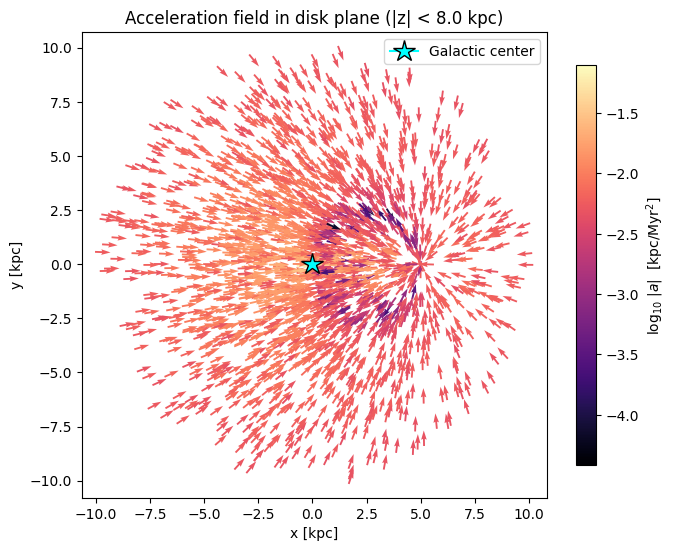

In [169]:
import numpy as np
import matplotlib.pyplot as plt

x = np.asarray(raw_datadict["x_train"])
a = np.asarray(raw_datadict["a_train"])


_, projected_accel = project_accelerations(a, x, np.array([5, 0, 0]))  # example point of view at (50, 0, 0)


amag = np.linalg.norm(projected_accel, axis=1)

# take a thin slab near the disk plane (z ≈ 0) — a real slice, not a squashed projection
z_cut = 8.0                          # kpc
slab = np.abs(x[:, 2]) < z_cut
xs, as_, amags = x[slab], projected_accel[slab], amag[slab]
print(f"points in |z| < {z_cut} kpc: {slab.sum()} of {len(x)}")

# normalize the in-plane arrows to unit length (direction only); color carries magnitude
axy = as_[:, :2]
axy_unit = axy / np.linalg.norm(axy, axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(7.5, 6.5))
q = ax.quiver(xs[:, 0], xs[:, 1], axy_unit[:, 0], axy_unit[:, 1],
              np.log10(amags), cmap="magma",
              angles="xy", scale=30, width=0.004, pivot="mid")
ax.plot(0, 0, marker="*", ms=16, color="cyan", mec="k", label="Galactic center")
ax.set_aspect("equal")
ax.set_xlabel("x [kpc]"); ax.set_ylabel("y [kpc]")
ax.set_title(f"Acceleration field in disk plane (|z| < {z_cut} kpc)")
ax.legend(loc="upper right")
fig.colorbar(q, ax=ax, shrink=0.8, label=r"$\log_{10}\,|a|$  [kpc/Myr$^2$]")
plt.show()


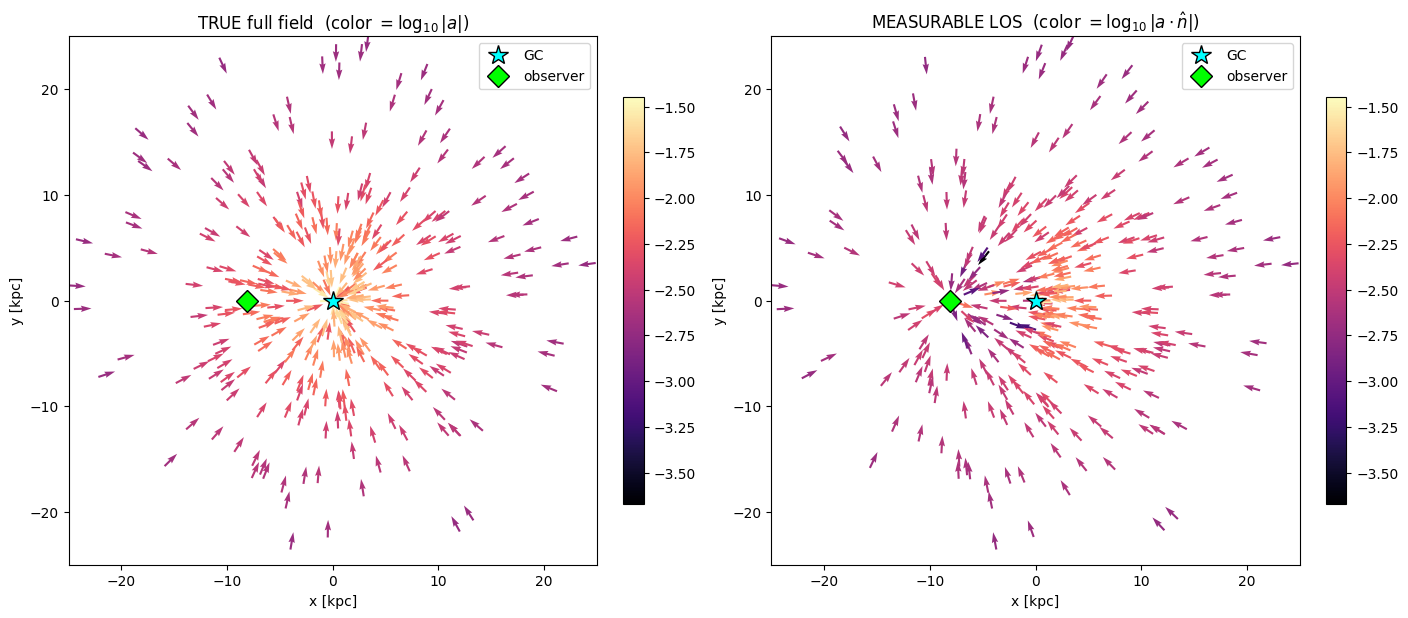

In [182]:
import numpy as np
import matplotlib.pyplot as plt

raw_datadict = generate_static_data(
    galax_potential=true_potential,
    n_samples_train=512,
    n_samples_test=4096,
    r_max_train=25,
    r_max_test=150,
)

x = np.asarray(raw_datadict["x_train"])
a = np.asarray(raw_datadict["a_train"])

pov = np.array([-8.1, 0.0, 0.0])                 # observer near the Sun's galactocentric position
dot, proj = project_accelerations(a, x, pov)     # dot = scalar a·n̂ (the datum); proj = (a·n̂)n̂ (vector)

z_cut = 8.0                                       # disk-plane slab
m = np.abs(x[:, 2]) < z_cut
xs, a_s, proj_s, dot_s = x[m], a[m], proj[m], dot[m]

# in-plane unit arrows for each panel (direction only; magnitude goes to color)
full_u = a_s[:, :2]  / np.linalg.norm(a_s[:, :2],  axis=1, keepdims=True)
proj_u = proj_s[:, :2] / (np.linalg.norm(proj_s[:, :2], axis=1, keepdims=True) + 1e-12)

cL = np.log10((np.linalg.norm(a_s, axis=1)))      # full |a|
cR = np.log10((np.abs(dot_s) + 1e-10))            # measurable |a·n̂|
vmin, vmax = min(cL.min(), cR.min()), max(cL.max(), cR.max())                   # SHARED scale → dimming on the right = information lost

view = (-25, 25)
fig, (axL, axR) = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)
for ax, u, c, ttl in [(axL, full_u, cL, r"TRUE full field  (color $=\log_{10}|a|$)"),
                      (axR, proj_u, cR, r"MEASURABLE LOS  (color $=\log_{10}|a\cdot\hat{n}|$)")]:
    q = ax.quiver(xs[:, 0], xs[:, 1], u[:, 0], u[:, 1], c,
                  cmap="magma", angles="xy", scale=30, width=0.004, pivot="mid")
    q.set_clim(vmin, vmax)                          # note: set_clim, NOT vmin=/vmax= (this mpl version rejects those on quiver)
    ax.plot(0, 0, "*", ms=15, color="cyan", mec="k", label="GC")
    ax.plot(pov[0], pov[1], "D", ms=11, color="lime", mec="k", label="observer")
    ax.set_aspect("equal"); ax.set_xlim(*view); ax.set_ylim(*view)
    ax.set_xlabel("x [kpc]"); ax.set_ylabel("y [kpc]"); ax.set_title(ttl)
    ax.legend(loc="upper right")
    fig.colorbar(q, ax=ax, shrink=0.75)
plt.show()


In [183]:
def project_accelerations(a, x, point_of_view=np.array([0.0, 0.0, 0.0]),
                          pov_acceleration=np.array([0.0, 0.0, 0.0])):
    """Project acceleration vectors onto the line of sight from an observer.

    Computes both the *absolute* LOS acceleration (a·n̂, the GC-frame projection)
    and the *Sun-relative* LOS acceleration ((a - a_obs)·n̂) — which is what a
    pulsar actually measures. With the default ``pov_acceleration`` of zero, the
    relative outputs reduce to the absolute ones.

    Parameters
    ----------
    a : np.ndarray, shape (N, 3)
        Acceleration vectors in the galactocentric (GC) frame.
    x : np.ndarray, shape (N, 3)
        Positions in the galactocentric frame [kpc].
    point_of_view : np.ndarray, shape (3,)
        Observer position [kpc]. Sightlines point observer -> point.
    pov_acceleration : np.ndarray, shape (3,)
        GC-frame acceleration at the observer, a_obs. Pass
        ``potential.acceleration(point_of_view)`` to get the true pulsar
        observable; leave at zero for the absolute projection only.

    Returns
    -------
    dict
        "n_vecs"  : (N, 3) unit sightline directions (observer -> point).
        "los_abs" : (N,)   absolute LOS accel, a·n̂.
        "vec_abs" : (N, 3) absolute projection, (a·n̂) n̂.
        "los_rel" : (N,)   Sun-relative LOS accel, (a - a_obs)·n̂  <-- pulsar observable.
        "vec_rel" : (N, 3) Sun-relative projection, ((a - a_obs)·n̂) n̂.
    """
    dx = x - point_of_view                              # observer -> point
    n_vecs = dx / np.linalg.norm(dx, axis=1)[:, None]

    # absolute (GC-frame) LOS projection
    los_abs = np.einsum("ij,ij->i", a, n_vecs)
    vec_abs = los_abs[:, None] * n_vecs

    # Sun-relative LOS projection (subtract the observer's own acceleration)
    rel_acc = a - pov_acceleration[None, :]
    los_rel = np.einsum("ij,ij->i", rel_acc, n_vecs)
    vec_rel = los_rel[:, None] * n_vecs

    return {
        "n_vecs": n_vecs,
        "los_abs": los_abs,
        "vec_abs": vec_abs,
        "los_rel": los_rel,
        "vec_rel": vec_rel,
    }


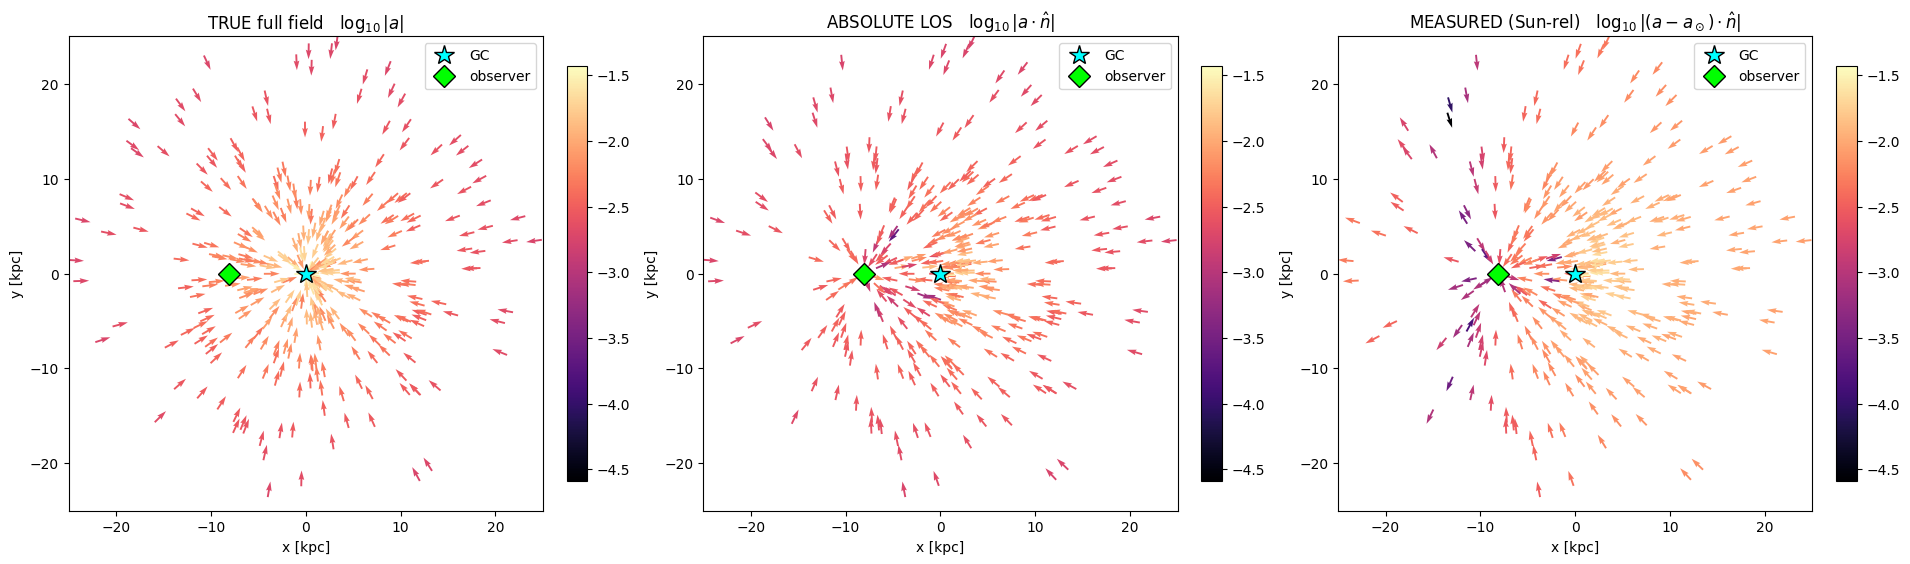

In [184]:
import numpy as np
import matplotlib.pyplot as plt
import unxt as u
import coordinax as cx

# a more LOCAL dataset just for this figure (separate var so we don't clobber the
# raw_datadict your model was trained on)
raw_viz = generate_static_data(
    galax_potential=true_potential,
    n_samples_train=512, n_samples_test=4096,
    r_max_train=25, r_max_test=150,
)
x = np.asarray(raw_viz["x_train"])
a = np.asarray(raw_viz["a_train"])

pov = np.array([-8.1, 0.0, 0.0])                        # observer near the Sun

# observer's OWN acceleration in the GC frame (drives the Sun-relative panel)
p = cx.CartesianPos3D(x=u.Quantity(pov[0], "kpc"),
                      y=u.Quantity(pov[1], "kpc"),
                      z=u.Quantity(pov[2], "kpc"))
acc = true_potential.acceleration(p, t=u.Quantity(0, "Myr"))
a_obs = np.array([acc.x.value.item(), acc.y.value.item(), acc.z.value.item()])

out = project_accelerations(a, x, pov, pov_acceleration=a_obs)

z_cut = 8.0
m = np.abs(x[:, 2]) < z_cut
xs = x[m]

def unit_xy(v):
    vv = v[m][:, :2]
    return vv / (np.linalg.norm(vv, axis=1, keepdims=True) + 1e-12)

panels = [
    (unit_xy(a),              np.log10(np.linalg.norm(a[m], axis=1)),      r"TRUE full field   $\log_{10}|a|$"),
    (unit_xy(out["vec_abs"]), np.log10(np.abs(out["los_abs"][m]) + 1e-10), r"ABSOLUTE LOS   $\log_{10}|a\cdot\hat n|$"),
    (unit_xy(out["vec_rel"]), np.log10(np.abs(out["los_rel"][m]) + 1e-10), r"MEASURED (Sun-rel)   $\log_{10}|(a-a_\odot)\cdot\hat n|$"),
]

allc = np.concatenate([c for _, c, _ in panels])        # shared color scale across all three
vmin, vmax = allc.min(), allc.max()

view = (-25, 25)
fig, axs = plt.subplots(1, 3, figsize=(19, 6), constrained_layout=True)
for ax, (u_arr, c, ttl) in zip(axs, panels):
    q = ax.quiver(xs[:, 0], xs[:, 1], u_arr[:, 0], u_arr[:, 1], c,
                  cmap="magma", angles="xy", scale=30, width=0.004, pivot="mid")
    q.set_clim(vmin, vmax)
    ax.plot(0, 0, "*", ms=15, color="cyan", mec="k", label="GC")
    ax.plot(pov[0], pov[1], "D", ms=11, color="lime", mec="k", label="observer")
    ax.set_aspect("equal"); ax.set_xlim(*view); ax.set_ylim(*view)
    ax.set_xlabel("x [kpc]"); ax.set_ylabel("y [kpc]"); ax.set_title(ttl)
    ax.legend(loc="upper right")
    fig.colorbar(q, ax=ax, shrink=0.7)
plt.show()


53 pulsars with a measured LOS acceleration


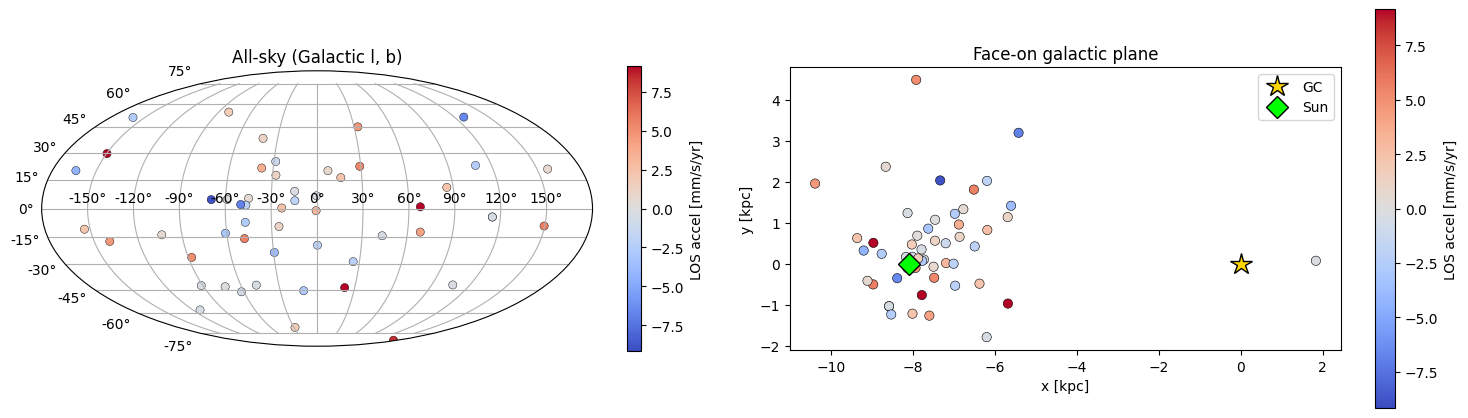

In [185]:
import numpy as np
import matplotlib.pyplot as plt

CSV = "/Users/pablom.perez/Desktop/Linas-group/data/pulsars/data.csv"

# columns (0-indexed): GL=1, GB=2, DIST=5, ALOS_PS=19/20, ALOS_PB=29/30.
# NOTE: file row 2 is a UNITS row -> skip_header=2
gl_deg, gb_deg, dist, alos_ps, alos_ps_err, alos_pb, alos_pb_err = np.genfromtxt(
    CSV, delimiter=",", skip_header=2, usecols=(1, 2, 5, 19, 20, 29, 30)
).T

# each pulsar's LOS acceleration: prefer spin-based (ALOS_PS), fall back to binary-based (ALOS_PB)
alos     = np.where(~np.isnan(alos_ps), alos_ps, alos_pb)
alos_err = np.where(~np.isnan(alos_ps), alos_ps_err, alos_pb_err)
good     = ~np.isnan(alos) & ~np.isnan(dist)
print(f"{good.sum()} pulsars with a measured LOS acceleration")

gl = np.deg2rad(gl_deg[good]); gb = np.deg2rad(gb_deg[good])
al = alos[good]; d = dist[good]

# heliocentric (l, b, dist) -> galactocentric Cartesian.
# Sun at (-R0, 0, 0); l=0,b=0 points from the Sun toward the GC (+x)
R0 = 8.1
xg = d*np.cos(gb)*np.cos(gl) - R0
yg = d*np.cos(gb)*np.sin(gl)

vlim = float(np.percentile(np.abs(al), 95))         # symmetric limits for the diverging map

fig = plt.figure(figsize=(15, 6))

# --- all-sky: where the pulsars sit on the sky (l increases leftward, GC at center) ---
ax1 = fig.add_subplot(1, 2, 1, projection="mollweide")
glw = np.remainder(gl_deg[good] + 180, 360) - 180   # wrap to [-180, 180]
sc = ax1.scatter(np.deg2rad(-glw), gb, c=al, cmap="coolwarm",
                 vmin=-vlim, vmax=vlim, s=35, ec="k", lw=0.3)
ax1.grid(True); ax1.set_title("All-sky (Galactic l, b)")
fig.colorbar(sc, ax=ax1, shrink=0.5, label="LOS accel [mm/s/yr]")

# --- face-on: where they are in 3D, relative to Sun & GC ---
ax2 = fig.add_subplot(1, 2, 2)
sc2 = ax2.scatter(xg, yg, c=al, cmap="coolwarm", vmin=-vlim, vmax=vlim, s=45, ec="k", lw=0.4)
ax2.plot(0, 0, "*", ms=16, color="gold", mec="k", label="GC")
ax2.plot(-R0, 0, "D", ms=11, color="lime", mec="k", label="Sun")
ax2.set_aspect("equal"); ax2.set_xlabel("x [kpc]"); ax2.set_ylabel("y [kpc]")
ax2.set_title("Face-on galactic plane"); ax2.legend(loc="upper right")
fig.colorbar(sc2, ax=ax2, shrink=0.7, label="LOS accel [mm/s/yr]")

plt.tight_layout(); plt.show()


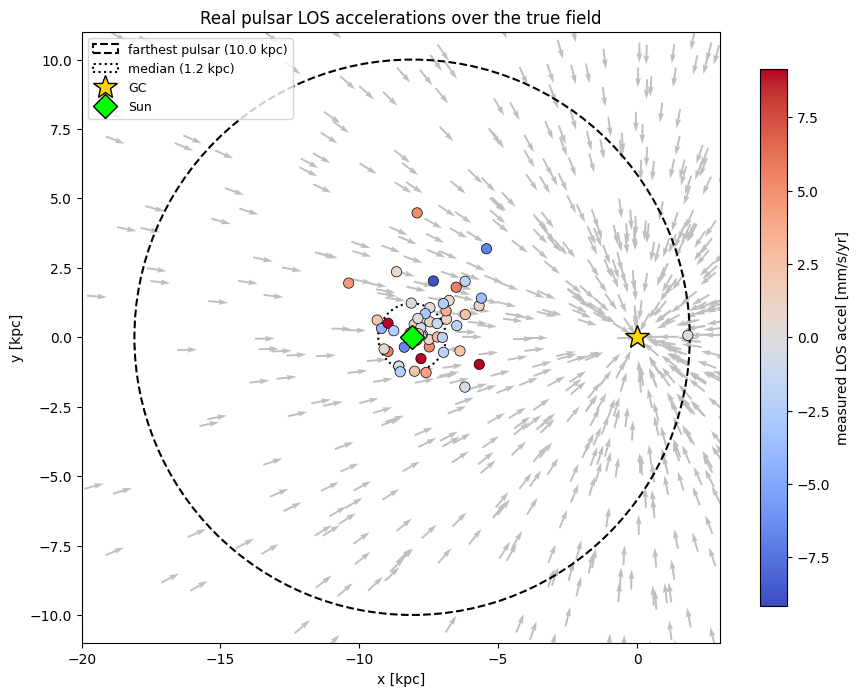

In [186]:
import numpy as np
import matplotlib.pyplot as plt
from galactoPINNs.data import generate_static_data

# --- (1) synthetic true field, as grey CONTEXT arrows (direction only) ---
raw_bg = generate_static_data(galax_potential=true_potential,
                              n_samples_train=1500, n_samples_test=10,
                              r_max_train=25, r_max_test=30)
xb = np.asarray(raw_bg["x_train"]); ab = np.asarray(raw_bg["a_train"])
mb = np.abs(xb[:, 2]) < 8.0                                   # disk slab
xs = xb[mb]
fu = ab[mb][:, :2] / np.linalg.norm(ab[mb][:, :2], axis=1, keepdims=True)

# --- (2) real pulsars (ALOS is already Sun-relative & Shklovskii-removed) ---
CSV = "/Users/pablom.perez/Desktop/Linas-group/data/pulsars/data.csv"
gl_deg, gb_deg, dist, aps, _, apb, _ = np.genfromtxt(
    CSV, delimiter=",", skip_header=2, usecols=(1, 2, 5, 19, 20, 29, 30)).T
al = np.where(~np.isnan(aps), aps, apb)
g  = ~np.isnan(al) & ~np.isnan(dist)
gl = np.deg2rad(gl_deg[g]); gb = np.deg2rad(gb_deg[g]); dp = dist[g]; alp = al[g]
R0 = 8.1
xp = dp*np.cos(gb)*np.cos(gl) - R0
yp = dp*np.cos(gb)*np.sin(gl)

# --- (3) field (grey) + data-bubble circles + pulsars (color) ---
vlim = float(np.percentile(np.abs(alp), 95))
fig, ax = plt.subplots(figsize=(9, 8))
ax.quiver(xs[:, 0], xs[:, 1], fu[:, 0], fu[:, 1], color="0.75",
          angles="xy", scale=32, width=0.003, pivot="mid", zorder=1)
for r, ls, lab in [(dp.max(), "--", f"farthest pulsar ({dp.max():.1f} kpc)"),
                   (np.median(dp), ":", f"median ({np.median(dp):.1f} kpc)")]:
    ax.add_patch(plt.Circle((-R0, 0), r, fill=False, ec="k", ls=ls, lw=1.5, zorder=3, label=lab))
sc = ax.scatter(xp, yp, c=alp, cmap="coolwarm", vmin=-vlim, vmax=vlim,
                s=55, ec="k", lw=0.5, zorder=4)
ax.plot(0, 0, "*", ms=18, color="gold", mec="k", zorder=5, label="GC")
ax.plot(-R0, 0, "D", ms=12, color="lime", mec="k", zorder=5, label="Sun")
ax.set_aspect("equal"); ax.set_xlim(-20, 3); ax.set_ylim(-11, 11)
ax.set_xlabel("x [kpc]"); ax.set_ylabel("y [kpc]")
ax.set_title("Real pulsar LOS accelerations over the true field")
ax.legend(loc="upper left", fontsize=9)
fig.colorbar(sc, ax=ax, shrink=0.7, label="measured LOS accel [mm/s/yr]")
plt.tight_layout(); plt.show()


kept 47 / 53 pulsars (fractional distance error < 1.0)


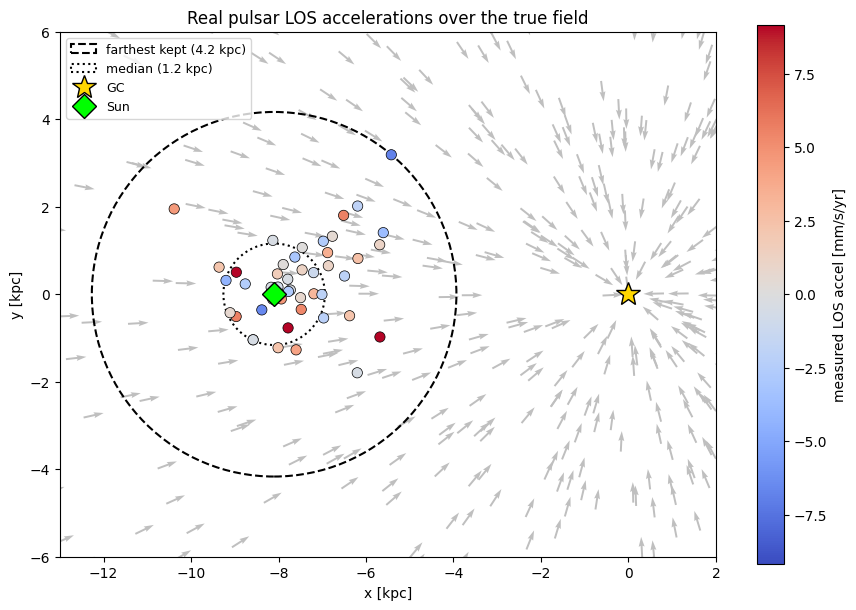

In [187]:
import numpy as np
import matplotlib.pyplot as plt
from galactoPINNs.data import generate_static_data

# --- (1) synthetic true field, as grey CONTEXT arrows (direction only) ---
raw_bg = generate_static_data(galax_potential=true_potential,
                              n_samples_train=1500, n_samples_test=10,
                              r_max_train=25, r_max_test=30)
xb = np.asarray(raw_bg["x_train"]); ab = np.asarray(raw_bg["a_train"])
mb = np.abs(xb[:, 2]) < 8.0
xs = xb[mb]
fu = ab[mb][:, :2] / np.linalg.norm(ab[mb][:, :2], axis=1, keepdims=True)

# --- (2) real pulsars, with a distance-quality cut ---
CSV = "/Users/pablom.perez/Desktop/Linas-group/data/pulsars/data.csv"
gl_deg, gb_deg, dist, derr, aps, _, apb, _ = np.genfromtxt(
    CSV, delimiter=",", skip_header=2, usecols=(1, 2, 5, 6, 19, 20, 29, 30)).T
al = np.where(~np.isnan(aps), aps, apb)

frac_err_max = 1.0        # keep only distances known to better than this fractional error
usable = ~np.isnan(al) & ~np.isnan(dist)
g = usable & (derr / dist < frac_err_max)
print(f"kept {g.sum()} / {usable.sum()} pulsars (fractional distance error < {frac_err_max})")

gl = np.deg2rad(gl_deg[g]); gb = np.deg2rad(gb_deg[g]); dp = dist[g]; alp = al[g]
R0 = 8.1
xp = dp*np.cos(gb)*np.cos(gl) - R0
yp = dp*np.cos(gb)*np.sin(gl)

# --- (3) field (grey) + data-bubble circles + pulsars (color) ---
vlim = float(np.percentile(np.abs(alp), 95))
fig, ax = plt.subplots(figsize=(9, 8))
ax.quiver(xs[:, 0], xs[:, 1], fu[:, 0], fu[:, 1], color="0.75",
          angles="xy", scale=32, width=0.003, pivot="mid", zorder=1)
for r, ls, lab in [(dp.max(), "--", f"farthest kept ({dp.max():.1f} kpc)"),
                   (np.median(dp), ":", f"median ({np.median(dp):.1f} kpc)")]:
    ax.add_patch(plt.Circle((-R0, 0), r, fill=False, ec="k", ls=ls, lw=1.5, zorder=3, label=lab))
sc = ax.scatter(xp, yp, c=alp, cmap="coolwarm", vmin=-vlim, vmax=vlim,
                s=55, ec="k", lw=0.5, zorder=4)
ax.plot(0, 0, "*", ms=18, color="gold", mec="k", zorder=5, label="GC")
ax.plot(-R0, 0, "D", ms=12, color="lime", mec="k", zorder=5, label="Sun")
ax.set_aspect("equal"); ax.set_xlim(-13, 2); ax.set_ylim(-6, 6)
ax.set_xlabel("x [kpc]"); ax.set_ylabel("y [kpc]")
ax.set_title("Real pulsar LOS accelerations over the true field")
ax.legend(loc="upper left", fontsize=9)
fig.colorbar(sc, ax=ax, shrink=0.7, label="measured LOS accel [mm/s/yr]")
plt.tight_layout(); plt.show()


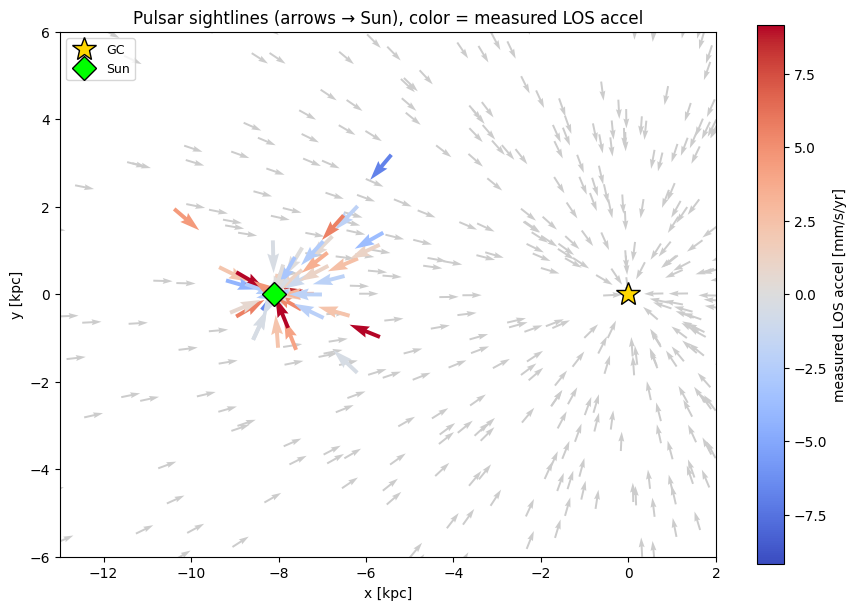

In [188]:
import numpy as np
import matplotlib.pyplot as plt
from galactoPINNs.data import generate_static_data

# grey CONTEXT field (points toward the GC)
raw_bg = generate_static_data(galax_potential=true_potential, n_samples_train=1500,
                              n_samples_test=10, r_max_train=25, r_max_test=30)
xb = np.asarray(raw_bg["x_train"]); ab = np.asarray(raw_bg["a_train"])
mb = np.abs(xb[:, 2]) < 8.0
xs = xb[mb]
fu = ab[mb][:, :2] / np.linalg.norm(ab[mb][:, :2], axis=1, keepdims=True)

# real pulsars (distance-quality cut)
CSV = "/Users/pablom.perez/Desktop/Linas-group/data/pulsars/data.csv"
gl_deg, gb_deg, dist, derr, aps, _, apb, _ = np.genfromtxt(
    CSV, delimiter=",", skip_header=2, usecols=(1, 2, 5, 6, 19, 20, 29, 30)).T
al = np.where(~np.isnan(aps), aps, apb)
g = ~np.isnan(al) & ~np.isnan(dist) & (derr / dist < 1.0)
gl = np.deg2rad(gl_deg[g]); gb = np.deg2rad(gb_deg[g]); dp = dist[g]; alp = al[g]
R0 = 8.1
xp = dp*np.cos(gb)*np.cos(gl) - R0
yp = dp*np.cos(gb)*np.sin(gl)

# unit arrow from each pulsar TOWARD the Sun (its line of sight)
to_sun = np.stack([-R0 - xp, -yp], axis=1)
to_sun /= np.linalg.norm(to_sun, axis=1, keepdims=True) + 1e-12

vlim = float(np.percentile(np.abs(alp), 95))
fig, ax = plt.subplots(figsize=(9, 8))
ax.quiver(xs[:, 0], xs[:, 1], fu[:, 0], fu[:, 1], color="0.8",           # field -> GC (context)
          angles="xy", scale=34, width=0.003, pivot="mid", zorder=1)
q = ax.quiver(xp, yp, to_sun[:, 0], to_sun[:, 1], alp, cmap="coolwarm",  # pulsars -> Sun
              angles="xy", scale=20, width=0.006, pivot="tail", zorder=4)
q.set_clim(-vlim, vlim)
ax.plot(0, 0, "*", ms=18, color="gold", mec="k", zorder=5, label="GC")
ax.plot(-R0, 0, "D", ms=12, color="lime", mec="k", zorder=5, label="Sun")
ax.set_aspect("equal"); ax.set_xlim(-13, 2); ax.set_ylim(-6, 6)
ax.set_xlabel("x [kpc]"); ax.set_ylabel("y [kpc]")
ax.set_title("Pulsar sightlines (arrows → Sun), color = measured LOS accel")
ax.legend(loc="upper left", fontsize=9)
fig.colorbar(q, ax=ax, shrink=0.7, label="measured LOS accel [mm/s/yr]")
plt.tight_layout(); plt.show()
